# HW14.ipynb

Домашняя работа по теме: эмбеддинги, индекс `FAISS`, оценка retrieval, обновление базы знаний и mini-RAG.

В ноутбуке:
- загружается небольшая база знаний по Flask;
- документы разбиваются на чанки;
- строятся векторные представления;
- собирается индекс `FAISS`;
- считается качество retrieval на контрольных запросах;
- проводится небольшой эксперимент по `chunk_size`;
- демонстрируется обновление базы знаний и переиндексация;
- собирается простой mini-RAG с возвратом источников.


In [1]:
# Если faiss не установлен, ставим faiss-cpu прямо из ноутбука.
import sys
import subprocess
import importlib

def ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        return importlib.import_module(import_name)

faiss = ensure_package("faiss", "faiss-cpu")


In [2]:
from pathlib import Path
import json
import math
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path.cwd()
ART_DIR = BASE_DIR / "artifacts"
KB_DIR = BASE_DIR / "knowledge_base"
ART_DIR.mkdir(exist_ok=True)
KB_DIR.mkdir(exist_ok=True)

print("Seed =", SEED)
print("faiss version =", getattr(faiss, "__version__", "unknown"))


Seed = 42
faiss version = 1.13.2


## 1. База знаний и первичный анализ

База знаний посвящена Flask-разработке. Это компактный тематический набор документов, на котором удобно показывать retrieval и mini-RAG: вопросы обычно соотносятся с конкретными темами, а ответы можно проверять вручную.


In [3]:
# Автоматически создаём файлы базы знаний, если их нет
default_initial_docs = [
  {
    "source_id": "doc_intro_app_structure",
    "title": "Структура Flask-приложения и app factory",
    "text": "Во Flask небольшое приложение можно начать с одного файла, но по мере роста кода удобнее переходить к структуре с пакетами, app factory и разделением модулей. Паттерн application factory позволяет создавать приложение функцией create_app и подключать расширения без жёсткой привязки к глобальному app. Такой подход упрощает тестирование, поддержку нескольких конфигураций и запуск разных окружений. Обычно рядом хранятся пакеты blueprints, шаблоны, static, модели и конфигурация. Если проект становится большим, имеет смысл выделить отдельные модули для auth, api, admin и main, чтобы маршруты и бизнес-логика были разнесены по понятным частям."
  },
  {
    "source_id": "doc_blueprints",
    "title": "Flask Blueprints для разбиения приложения на модули",
    "text": "Blueprints помогают разделить большое Flask-приложение на несколько логических частей. Каждый blueprint может содержать собственные маршруты, шаблоны, static-файлы и обработчики ошибок. Например, можно завести blueprints для auth, blog и api, а затем зарегистрировать их внутри create_app. Это делает код модульным и облегчает командную разработку. Blueprint не является отдельным приложением, но даёт удобный способ группировать view-функции по разделам. Для больших систем полезно выносить URL-префиксы и регистрацию маршрутов в отдельные файлы, чтобы навигация по проекту оставалась простой."
  },
  {
    "source_id": "doc_jinja_templates",
    "title": "Jinja-шаблоны и передача данных в HTML",
    "text": "Во Flask HTML обычно рендерится через Jinja2. View-функция получает данные, а затем передаёт их в шаблон через render_template. Это позволяет отделить Python-логику от разметки. В шаблонах удобно использовать наследование через base.html, блоки content и повторно использовать макросы. Так снижается дублирование HTML и проще поддерживать общий layout сайта. Если нужно вывести список объектов, их передают в render_template как именованные аргументы. Jinja также умеет фильтры, условия и циклы, поэтому подходит для большинства типовых страниц и административных интерфейсов."
  },
  {
    "source_id": "doc_forms_validation",
    "title": "Формы, валидация и паттерн Post/Redirect/Get",
    "text": "При работе с HTML-формами во Flask полезно придерживаться паттерна Post/Redirect/Get. После успешной обработки POST-запроса приложение делает redirect, чтобы пользователь не отправил форму повторно при обновлении страницы. Для проверки данных применяют серверную валидацию и сообщения flash. Формы можно обрабатывать вручную через request.form или использовать Flask-WTF для CSRF-защиты и декларативных правил. Основная идея состоит в том, чтобы не смешивать проверку входных значений, бизнес-логику и финальный рендер ответа."
  },
  {
    "source_id": "doc_rest_api_json",
    "title": "JSON API и HTTP-коды во Flask",
    "text": "Для JSON API во Flask удобно возвращать данные через jsonify или обычный dict в новых версиях фреймворка. Важно выставлять корректные HTTP-коды: 200 для успешного чтения, 201 для создания, 400 для ошибок клиента, 404 для отсутствующего ресурса и 500 для внутренних сбоев. Если приложение предоставляет REST API, полезно описать единый формат ошибок и структуру ответа. Тестировать такие маршруты удобно через test client, проверяя body, headers и status code. При проектировании API стоит отдельно подумать о сериализации, пагинации и валидации входного JSON."
  },
  {
    "source_id": "doc_config_secrets",
    "title": "Конфигурация Flask и хранение секретов",
    "text": "Конфигурацию Flask-приложения лучше хранить отдельно от исходного кода. SECRET_KEY, строки подключения, токены и другие секреты не стоит коммитить в репозиторий. Обычно значения берут из переменных окружения, .env-файлов или конфигурационных классов для dev, test и production. Так проще безопасно переключаться между окружениями. В create_app можно загрузить настройки через app.config.from_object или from_mapping. Главное правило — держать секреты вне публичного кода и документировать обязательные переменные окружения для запуска проекта."
  },
  {
    "source_id": "doc_sessions_auth",
    "title": "Сессии пользователя и Flask-Login",
    "text": "Flask-Login помогает организовать аутентификацию пользователей и управление сессией. Он хранит идентификатор пользователя в session и предоставляет current_user, login_user и logout_user. Сама session во Flask по умолчанию подписывается SECRET_KEY и хранится на стороне клиента в cookie. Поэтому нужно внимательно относиться к секретному ключу и времени жизни сессии. Для авторизации обычно добавляют декоратор login_required и пользовательский loader. Если нужны роли и права доступа, их часто реализуют отдельно поверх механизма входа в систему."
  },
  {
    "source_id": "doc_sqlalchemy_models",
    "title": "SQLAlchemy, модели и миграции",
    "text": "Для работы с базой данных во Flask часто используют Flask-SQLAlchemy и Flask-Migrate. ORM позволяет описывать таблицы в виде Python-моделей и работать с ними через session. Миграции помогают согласованно изменять схему базы между версиями приложения. Обычно workflow выглядит так: описать model, выполнить flask db migrate и затем flask db upgrade. Это особенно удобно при командной разработке. Если в проекте есть API и веб-интерфейс, модели становятся центральной частью приложения, поэтому важно продумать связи, индексы и ограничения."
  },
  {
    "source_id": "doc_testing_pytest",
    "title": "Тестирование Flask через pytest и test client",
    "text": "Flask-приложения удобно тестировать с помощью pytest и встроенного test client. Фикстуры позволяют создать приложение в режиме TESTING, отдельную базу данных и клиента для запросов. Через test client можно отправлять GET и POST, проверять статус ответа, заголовки, HTML и JSON. Для API полезно писать тесты на успешные сценарии и на ошибки валидации. Если приложение использует app factory, фикстуры становятся особенно удобными. Такой подход помогает стабильно проверять маршруты, формы, JSON API и взаимодействие с базой данных."
  },
  {
    "source_id": "doc_logging_monitoring",
    "title": "Логирование ошибок и мониторинг Flask",
    "text": "В production Flask-приложению нужны логирование и наблюдаемость. Минимальный уровень — писать структурированные логи, не терять traceback и разделять access и application logs. Полезно отправлять ошибки в внешнюю систему мониторинга, например Sentry, и настраивать алерты по частоте падений. Для диагностики помогают request id, уровень severity и единый формат сообщений. Если приложение работает за Gunicorn, важно собирать и логи воркеров, и логи reverse proxy. Хорошее логирование ускоряет разбор инцидентов и помогает увидеть деградации до жалоб пользователей."
  },
  {
    "source_id": "doc_deployment_gunicorn_nginx",
    "title": "Развёртывание Flask за Gunicorn и Nginx",
    "text": "Для production Flask обычно запускают не встроенным development server, а через Gunicorn или uWSGI. Снаружи часто ставят Nginx как reverse proxy: он завершает TLS, раздаёт static и проксирует запросы во Flask-приложение. Такой стек лучше подходит для стабильной работы, логирования и масштабирования. Gunicorn поднимает несколько worker-процессов, а Nginx защищает приложение и распределяет входящий трафик. При развёртывании важно настроить systemd, переменные окружения и таймауты прокси. В результате приложение работает надёжнее, чем при запуске через flask run."
  },
  {
    "source_id": "doc_error_handlers",
    "title": "Обработчики ошибок и пользовательские страницы 404/500",
    "text": "Во Flask можно регистрировать обработчики ошибок через errorhandler. Это полезно для красивых страниц 404 и 500, а также для единообразных JSON-ответов в API. Если приложение смешивает веб-страницы и API, стоит отдельно продумать формат ошибок для разных частей системы. Хороший обработчик ошибок не скрывает проблему, а логирует детали и возвращает понятный пользователю ответ. В production не следует показывать внутренние traceback-концы пользователю, но их стоит сохранять в логах и мониторинге."
  }
]
default_update_docs = [
  {
    "source_id": "doc_caching_redis",
    "title": "Кэширование во Flask и Redis",
    "text": "Если Flask-приложение часто выполняет дорогие вычисления или повторяет одинаковые запросы, полезно добавить кэширование. Для этого часто используют Redis и библиотеку Flask-Caching. Кэш можно применять для целых view, фрагментов шаблонов или результатов функций. Важно выбрать TTL и стратегию инвалидирования, иначе пользователи будут видеть устаревшие данные. Redis удобен тем, что хранит значения в памяти и хорошо подходит для быстрых lookup-операций и shared cache между воркерами."
  },
  {
    "source_id": "doc_rate_limiting",
    "title": "Rate limiting для публичного Flask API",
    "text": "Публичный API во Flask стоит защищать ограничением частоты запросов. Часто для этого используют Flask-Limiter. Rate limiting помогает предотвратить злоупотребления, защититься от шумных клиентов и снизить риск перегрузки. Лимиты можно задавать по IP, токену или пользователю, а ответы сопровождать кодом 429 Too Many Requests. Если API работает за reverse proxy, нужно корректно учитывать реальный IP клиента и доверенные заголовки."
  },
  {
    "source_id": "doc_sse_vs_websocket",
    "title": "SSE и WebSocket во Flask",
    "text": "Для однонаправленной доставки событий от сервера к браузеру во Flask иногда достаточно Server-Sent Events. SSE проще настроить, если нужно только потоковое обновление статусов, логов или прогресса задач. WebSocket подходит, когда требуется двусторонний интерактивный канал между клиентом и сервером. Поэтому SSE часто выбирают для простых уведомлений, а WebSocket — для чатов, совместного редактирования и других интерактивных сценариев."
  }
]

initial_docs_path = KB_DIR / "knowledge_base_initial.json"
updates_docs_path = KB_DIR / "knowledge_base_updates.json"

if not initial_docs_path.exists():
    with open(initial_docs_path, "w", encoding="utf-8") as f:
        json.dump(default_initial_docs, f, ensure_ascii=False, indent=2)

if not updates_docs_path.exists():
    with open(updates_docs_path, "w", encoding="utf-8") as f:
        json.dump(default_update_docs, f, ensure_ascii=False, indent=2)

docs = pd.read_json(initial_docs_path).to_dict("records")
new_docs = pd.read_json(updates_docs_path).to_dict("records")

print("Число исходных документов:", len(docs))
print("Число новых документов для обновления:", len(new_docs))

docs_df = pd.DataFrame(docs)
docs_df[["source_id", "title"]]


Число исходных документов: 12
Число новых документов для обновления: 3


,source_id,title
0,doc_intro_app_structure,Структура Flask-приложения и app factory
1,doc_blueprints,Flask Blueprints для разбиения приложения на м...
2,doc_jinja_templates,Jinja-шаблоны и передача данных в HTML
3,doc_forms_validation,"Формы, валидация и паттерн Post/Redirect/Get"
4,doc_rest_api_json,JSON API и HTTP-коды во Flask
5,doc_config_secrets,Конфигурация Flask и хранение секретов
6,doc_sessions_auth,Сессии пользователя и Flask-Login
7,doc_sqlalchemy_models,"SQLAlchemy, модели и миграции"
8,doc_testing_pytest,Тестирование Flask через pytest и test client
9,doc_logging_monitoring,Логирование ошибок и мониторинг Flask


In [4]:
for i, doc in enumerate(docs[:3], start=1):
    print("=" * 80)
    print(f"Пример документа {i}: {doc['title']} ({doc['source_id']})")
    print(doc["text"][:600], "...")
    print()


Пример документа 1: Структура Flask-приложения и app factory (doc_intro_app_structure)
Во Flask небольшое приложение можно начать с одного файла, но по мере роста кода удобнее переходить к структуре с пакетами, app factory и разделением модулей. Паттерн application factory позволяет создавать приложение функцией create_app и подключать расширения без жёсткой привязки к глобальному app. Такой подход упрощает тестирование, поддержку нескольких конфигураций и запуск разных окружений. Обычно рядом хранятся пакеты blueprints, шаблоны, static, модели и конфигурация. Если проект становится большим, имеет смысл выделить отдельные модули для auth, api, admin и main, чтобы маршруты и бизн ...

Пример документа 2: Flask Blueprints для разбиения приложения на модули (doc_blueprints)
Blueprints помогают разделить большое Flask-приложение на несколько логических частей. Каждый blueprint может содержать собственные маршруты, шаблоны, static-файлы и обработчики ошибок. Например, можно завести blueprin

## 2. Чанкинг документов

Используем простой воспроизводимый чанкинг: разбиваем текст на перекрывающиеся фрагменты по словам. В обязательной части этого достаточно: нам не нужен сложный semantic chunking, важно лишь получить разумные фрагменты для retrieval.


In [5]:
def normalize_text(s):
    return re.sub(r"\s+", " ", s).strip()

def chunk_text(text, chunk_size=320, overlap=80):
    words = normalize_text(text).split()
    chunks = []
    start = 0

    while start < len(words):
        cur_words = []
        cur_len = 0
        i = start

        while i < len(words):
            w = words[i]
            add = len(w) + (1 if cur_words else 0)
            if cur_words and cur_len + add > chunk_size:
                break
            cur_words.append(w)
            cur_len += add
            i += 1

        if not cur_words:
            cur_words = [words[start]]
            i = start + 1

        chunks.append(" ".join(cur_words))

        if i >= len(words):
            break

        back = 0
        j = i - 1
        while j > start and back < overlap:
            back += len(words[j]) + 1
            j -= 1
        start = max(start + 1, j + 1)

    return chunks

def build_chunks(documents, chunk_size=320, overlap=80):
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk in enumerate(chunks):
            rows.append({
                "source_id": doc["source_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['source_id']}::chunk_{idx}",
                "chunk_index": idx,
                "text": chunk,
                "embed_text": f"{doc['title']}. {chunk}",
            })
    return pd.DataFrame(rows)

chunk_size_main = 320
overlap_main = 80

chunks_df = build_chunks(docs, chunk_size=chunk_size_main, overlap=overlap_main)
print("Число чанков:", len(chunks_df))
chunks_df.head()


Число чанков: 31


,source_id,title,chunk_id,chunk_index,text,embed_text
0,doc_intro_app_structure,Структура Flask-приложения и app factory,doc_intro_app_structure::chunk_0,0,Во Flask небольшое приложение можно начать с о...,Структура Flask-приложения и app factory. Во F...
1,doc_intro_app_structure,Структура Flask-приложения и app factory,doc_intro_app_structure::chunk_1,1,create_app и подключать расширения без жёсткой...,Структура Flask-приложения и app factory. crea...
2,doc_intro_app_structure,Структура Flask-приложения и app factory,doc_intro_app_structure::chunk_2,2,модели и конфигурация. Если проект становится ...,Структура Flask-приложения и app factory. моде...
3,doc_blueprints,Flask Blueprints для разбиения приложения на м...,doc_blueprints::chunk_0,0,Blueprints помогают разделить большое Flask-пр...,Flask Blueprints для разбиения приложения на м...
4,doc_blueprints,Flask Blueprints для разбиения приложения на м...,doc_blueprints::chunk_1,1,"и api, а затем зарегистрировать их внутри crea...",Flask Blueprints для разбиения приложения на м...


In [6]:
sample_doc_id = "doc_deployment_gunicorn_nginx"
sample_doc = next(d for d in docs if d["source_id"] == sample_doc_id)
sample_chunks = build_chunks([sample_doc], chunk_size=chunk_size_main, overlap=overlap_main)

print("Документ:", sample_doc["title"])
for _, row in sample_chunks.iterrows():
    print("-" * 80)
    print(row["chunk_id"])
    print(row["text"])


Документ: Развёртывание Flask за Gunicorn и Nginx
--------------------------------------------------------------------------------
doc_deployment_gunicorn_nginx::chunk_0
Для production Flask обычно запускают не встроенным development server, а через Gunicorn или uWSGI. Снаружи часто ставят Nginx как reverse proxy: он завершает TLS, раздаёт static и проксирует запросы во Flask-приложение. Такой стек лучше подходит для стабильной работы, логирования и масштабирования. Gunicorn поднимает
--------------------------------------------------------------------------------
doc_deployment_gunicorn_nginx::chunk_1
подходит для стабильной работы, логирования и масштабирования. Gunicorn поднимает несколько worker-процессов, а Nginx защищает приложение и распределяет входящий трафик. При развёртывании важно настроить systemd, переменные окружения и таймауты прокси. В результате приложение работает надёжнее, чем при запуске через
------------------------------------------------------------------------

## 3. Эмбеддинги и индекс FAISS

В качестве векторизации используем `TF-IDF` по словам и биграммам. После L2-нормализации можно использовать `FAISS IndexFlatIP`, а inner product на нормализованных векторах будет соответствовать cosine similarity.


In [7]:
def build_faiss_index(chunks_df):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=6000)
    X = vectorizer.fit_transform(chunks_df["embed_text"]).astype(np.float32)
    X = normalize(X, norm="l2", copy=False)
    dense = X.toarray().astype("float32")

    index = faiss.IndexFlatIP(dense.shape[1])
    index.add(dense)
    return vectorizer, index, dense

def search(query, vectorizer, index, chunks_df, top_k=3):
    q = vectorizer.transform([query]).astype(np.float32)
    q = normalize(q, norm="l2", copy=False)
    q_dense = q.toarray().astype("float32")

    scores, idx = index.search(q_dense, top_k)
    results = chunks_df.iloc[idx[0]].copy().reset_index(drop=True)
    results["score"] = scores[0]
    return results

def dedup_preserve(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

vectorizer, index, dense = build_faiss_index(chunks_df)
top_k_main = 3
print("FAISS index ntotal =", index.ntotal)


FAISS index ntotal = 31


## Проверка результата векторизации чанков

Ниже я явно показываю результат векторизации:
- форму матрицы эмбеддингов;
- размерность одного вектора;
- несколько первых координат для первых чанков.

Так видно, что чанки действительно были преобразованы в числовые векторы перед построением индекса `FAISS`.


In [8]:
# Явная демонстрация результата векторизации чанков

import pandas as pd
import numpy as np

# Сначала ищем фактическую матрицу эмбеддингов под типичными именами.
# В этом ноутбуке после build_faiss_index(...) векторы чанков лежат в переменной `dense`.
emb_candidates = [
    "dense",
    "chunk_embeddings",
    "chunk_vectors",
    "embeddings",
    "X_embeddings",
    "kb_embeddings",
]

emb_name = None
emb_arr = None

for name in emb_candidates:
    if name in globals():
        candidate = np.asarray(globals()[name])
        if candidate.ndim == 2:
            emb_name = name
            emb_arr = candidate
            break

if emb_arr is None:
    available = sorted([k for k in globals().keys() if not k.startswith("_")])[:80]
    raise NameError(
        "Не найдена матрица эмбеддингов чанков. "
        "Ожидалась одна из переменных: "
        + ", ".join(emb_candidates)
        + ". Доступные имена в globals(): "
        + ", ".join(available)
    )

print("Имя переменной с эмбеддингами:", emb_name)
print("Форма матрицы эмбеддингов:", emb_arr.shape)
print("Размерность одного вектора:", emb_arr.shape[1])

texts = None

if "chunks_df" in globals() and isinstance(chunks_df, pd.DataFrame):
    if "chunk_text" in chunks_df.columns:
        texts = chunks_df["chunk_text"].astype(str).tolist()
    elif "text" in chunks_df.columns:
        texts = chunks_df["text"].astype(str).tolist()

if texts is None and "chunk_df" in globals() and isinstance(chunk_df, pd.DataFrame):
    if "chunk_text" in chunk_df.columns:
        texts = chunk_df["chunk_text"].astype(str).tolist()
    elif "text" in chunk_df.columns:
        texts = chunk_df["text"].astype(str).tolist()

if texts is None and "chunks" in globals():
    if isinstance(chunks, list):
        if len(chunks) > 0 and isinstance(chunks[0], dict) and "chunk_text" in chunks[0]:
            texts = [str(x["chunk_text"]) for x in chunks]
        else:
            texts = [str(x) for x in chunks]

if texts is None and "chunk_texts" in globals():
    texts = [str(x) for x in chunk_texts]

if texts is None:
    texts = [""] * len(emb_arr)

preview_rows = min(5, len(emb_arr))
preview_dims = min(8, emb_arr.shape[1])

preview_dict = {
    "chunk_preview": [t[:120].replace("\n", " ") for t in texts[:preview_rows]]
}
for j in range(preview_dims):
    preview_dict[f"dim_{j}"] = emb_arr[:preview_rows, j]

preview_df = pd.DataFrame(preview_dict)
preview_df


Имя переменной с эмбеддингами: dense
Форма матрицы эмбеддингов: (31, 1366)
Размерность одного вектора: 1366


,chunk_preview,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Во Flask небольшое приложение можно начать с о...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,create_app и подключать расширения без жёсткой...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,модели и конфигурация. Если проект становится ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Blueprints помогают разделить большое Flask-пр...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"и api, а затем зарегистрировать их внутри crea...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
example_queries = [
    "Как сгруппировать маршруты по разделам приложения?",
    "Какой паттерн помогает избежать повторной отправки формы?",
    "Как разворачивать Flask за Gunicorn и Nginx?",
    "Как вернуть JSON-ответ клиенту?",
    "Как вынести секреты из исходного кода?",
]

for q in example_queries:
    print("=" * 100)
    print("QUERY:", q)
    res = search(q, vectorizer, index, chunks_df, top_k=3)
    print(res[["source_id", "score"]])
    print("TOP TEXT:", res.loc[0, "text"])
    print()


QUERY: Как сгруппировать маршруты по разделам приложения?
                 source_id     score
0           doc_blueprints  0.158372
1  doc_intro_app_structure  0.093734
2           doc_blueprints  0.062224
TOP TEXT: и api, а затем зарегистрировать их внутри create_app. Это делает код модульным и облегчает командную разработку. Blueprint не является отдельным приложением, но даёт удобный способ группировать view-функции по разделам. Для больших систем полезно выносить URL-префиксы и регистрацию маршрутов в отдельные файлы, чтобы

QUERY: Какой паттерн помогает избежать повторной отправки формы?
              source_id     score
0  doc_forms_validation  0.168760
1  doc_forms_validation  0.153181
2    doc_testing_pytest  0.111474
TOP TEXT: данных применяют серверную валидацию и сообщения flash. Формы можно обрабатывать вручную через request.form или использовать Flask-WTF для CSRF-защиты и декларативных правил. Основная идея состоит в том, чтобы не смешивать проверку входных значений, бизн

## 4. Контрольные запросы и оценка retrieval

Для оценки retrieval используем небольшой набор контрольных запросов с заранее заданными релевантными источниками. Считаем минимум `hit@k` и `recall@k`, дополнительно — `MRR@k`.


In [10]:
queries = [
    {"query": "Как разделить большое Flask-приложение на несколько модулей с маршрутами?", "expected_sources": ["doc_blueprints"]},
    {"query": "Как передать данные из view-функции в HTML-шаблон?", "expected_sources": ["doc_jinja_templates"]},
    {"query": "Чем лучше запускать Flask в production за reverse proxy?", "expected_sources": ["doc_deployment_gunicorn_nginx"]},
    {"query": "Где хранить SECRET_KEY и другие секреты приложения?", "expected_sources": ["doc_config_secrets"]},
    {"query": "Как тестировать маршруты и JSON API во Flask?", "expected_sources": ["doc_testing_pytest", "doc_rest_api_json"]},
    {"query": "Как работать с формами и избежать повторной отправки после POST?", "expected_sources": ["doc_forms_validation"]},
    {"query": "Для чего нужен Flask-Login и где хранится сессия пользователя?", "expected_sources": ["doc_sessions_auth"]},
    {"query": "Как настроить ORM и миграции для базы данных во Flask?", "expected_sources": ["doc_sqlalchemy_models"]},
    {"query": "Как логировать ошибки и отправлять логи в мониторинг?", "expected_sources": ["doc_logging_monitoring"]},
    {"query": "Как вернуть JSON и правильно выставлять HTTP-коды ответа?", "expected_sources": ["doc_rest_api_json"]},
]

rows = []
for item in queries:
    res = search(item["query"], vectorizer, index, chunks_df, top_k=top_k_main)
    retrieved_sources = dedup_preserve(res["source_id"].tolist())
    expected = item["expected_sources"]

    hit = int(any(s in retrieved_sources[:top_k_main] for s in expected))
    recall = sum(s in retrieved_sources[:top_k_main] for s in expected) / len(expected)

    rank = ""
    for i, s in enumerate(retrieved_sources[:top_k_main], start=1):
        if s in expected:
            rank = i
            break

    rows.append({
        "query": item["query"],
        "expected_source": " | ".join(expected),
        "retrieved_sources": " | ".join(retrieved_sources[:top_k_main]),
        "hit_at_k": hit,
        "recall_at_k": recall,
        "rank_of_first_relevant": rank,
    })

retrieval_eval = pd.DataFrame(rows)
hit_at_k = float(retrieval_eval["hit_at_k"].mean())
recall_at_k = float(retrieval_eval["recall_at_k"].mean())
mrr_at_k = float(np.mean([1 / x if x != "" else 0 for x in retrieval_eval["rank_of_first_relevant"]]))

print("hit@3 =", round(hit_at_k, 3))
print("recall@3 =", round(recall_at_k, 3))
print("MRR@3 =", round(mrr_at_k, 3))

retrieval_eval


hit@3 = 1.0
recall@3 = 0.95
MRR@3 = 1.0


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,Как разделить большое Flask-приложение на неск...,doc_blueprints,doc_blueprints | doc_deployment_gunicorn_nginx...,1,1.0,1
1,Как передать данные из view-функции в HTML-шаб...,doc_jinja_templates,doc_jinja_templates | doc_blueprints,1,1.0,1
2,Чем лучше запускать Flask в production за reve...,doc_deployment_gunicorn_nginx,doc_deployment_gunicorn_nginx | doc_logging_mo...,1,1.0,1
3,Где хранить SECRET_KEY и другие секреты прилож...,doc_config_secrets,doc_config_secrets | doc_sessions_auth,1,1.0,1
4,Как тестировать маршруты и JSON API во Flask?,doc_testing_pytest | doc_rest_api_json,doc_rest_api_json,1,0.5,1
5,Как работать с формами и избежать повторной от...,doc_forms_validation,doc_forms_validation | doc_sqlalchemy_models |...,1,1.0,1
6,Для чего нужен Flask-Login и где хранится сесс...,doc_sessions_auth,doc_sessions_auth,1,1.0,1
7,Как настроить ORM и миграции для базы данных в...,doc_sqlalchemy_models,doc_sqlalchemy_models | doc_rest_api_json | do...,1,1.0,1
8,Как логировать ошибки и отправлять логи в мони...,doc_logging_monitoring,doc_logging_monitoring,1,1.0,1
9,Как вернуть JSON и правильно выставлять HTTP-к...,doc_rest_api_json,doc_rest_api_json,1,1.0,1


## 5. Небольшой эксперимент по параметрам retrieval

Сравним два значения `chunk_size`: `320` и `480`. Это простой и понятный способ посмотреть, меняется ли качество retrieval при более локальных или более крупных фрагментах.


In [11]:
experiment_results = []
for cs in [320, 480]:
    chunks_tmp = build_chunks(docs, chunk_size=cs, overlap=80)
    vec_tmp, index_tmp, _ = build_faiss_index(chunks_tmp)

    hits, recalls = [], []
    for item in queries:
        res = search(item["query"], vec_tmp, index_tmp, chunks_tmp, top_k=3)
        retrieved_sources = dedup_preserve(res["source_id"].tolist())
        expected = item["expected_sources"]

        hits.append(int(any(s in retrieved_sources[:3] for s in expected)))
        recalls.append(sum(s in retrieved_sources[:3] for s in expected) / len(expected))

    experiment_results.append({
        "chunk_size": cs,
        "overlap": 80,
        "num_chunks": len(chunks_tmp),
        "hit_at_3": float(np.mean(hits)),
        "recall_at_3": float(np.mean(recalls)),
    })

experiment_df = pd.DataFrame(experiment_results)
experiment_df


,chunk_size,overlap,num_chunks,hit_at_3,recall_at_3
0,320,80,31,1.0,0.95
1,480,80,24,1.0,1.00


## 6. Обновление базы знаний и переиндексация

Добавляем 3 новых документа: про кэширование, rate limiting и варианты почти realtime-обновлений. Затем полностью повторяем чанкинг, векторизацию и построение индекса.


In [12]:
docs_updated = docs + new_docs

chunks_before = build_chunks(docs, chunk_size=chunk_size_main, overlap=overlap_main)
vec_before, index_before, _ = build_faiss_index(chunks_before)

chunks_after = build_chunks(docs_updated, chunk_size=chunk_size_main, overlap=overlap_main)
vec_after, index_after, _ = build_faiss_index(chunks_after)

update_queries = [
    "Как добавить кэширование результатов и хранить кэш в Redis?",
    "Чем ограничить частоту запросов к публичному API?",
    "Когда лучше использовать SSE вместо WebSocket во Flask?",
    "Как запускать Flask в production за reverse proxy?",
]

before_after_rows = []
for q in update_queries:
    before_res = search(q, vec_before, index_before, chunks_before, top_k=3)
    after_res = search(q, vec_after, index_after, chunks_after, top_k=3)

    before_sources = " | ".join(dedup_preserve(before_res["source_id"].tolist()))
    after_sources = " | ".join(dedup_preserve(after_res["source_id"].tolist()))

    before_after_rows.append({
        "query": q,
        "before_retrieved_sources": before_sources,
        "after_retrieved_sources": after_sources,
        "changed": before_sources != after_sources,
    })

retrieval_before_after_update = pd.DataFrame(before_after_rows)
retrieval_before_after_update


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как добавить кэширование результатов и хранить...,doc_config_secrets | doc_jinja_templates | doc...,doc_caching_redis | doc_config_secrets,True
1,Чем ограничить частоту запросов к публичному API?,doc_deployment_gunicorn_nginx | doc_testing_py...,doc_deployment_gunicorn_nginx | doc_rate_limit...,True
2,Когда лучше использовать SSE вместо WebSocket ...,doc_jinja_templates | doc_deployment_gunicorn_...,doc_sse_vs_websocket | doc_jinja_templates,True
3,Как запускать Flask в production за reverse pr...,doc_deployment_gunicorn_nginx | doc_logging_mo...,doc_rate_limiting | doc_deployment_gunicorn_ng...,True


## 7. Mini-RAG

Здесь используется простой учебный mini-RAG:
1. берём вопрос пользователя;
2. извлекаем `top-k` чанков;
3. собираем контекст из найденных фрагментов;
4. выбираем предложения с максимальным пересечением по токенам с вопросом;
5. возвращаем ответ вместе с источниками.


In [13]:
STOPWORDS = set("и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по только ее мне было вот от меня еще нет о из ему теперь когда даже ну вдруг ли если уже или ни быть был него до вас нибудь опять уж вам ведь там потом себя ничего ей может они тут где есть надо ней для мы тебя их чем была сам чтоб без будто чего раз тоже себе под будет ж тогда кто этот того потому этого какой совсем ним здесь этом один почти мой тем чтобы нее сейчас были куда зачем всех никогда можно при наконец два об другой хоть после над больше тот через эти нас про всего них какая много разве три эту моя впрочем хорошо свою этой перед иногда лучше чуть том нельзя такой им более всегда конечно всю между".split())

def tokenize_ru(text):
    return [t for t in re.findall(r"[A-Za-zА-Яа-яЁё0-9_]+", text.lower()) if t not in STOPWORDS and len(t) > 2]

def build_rag_answer(question, vectorizer, index, chunks_df, top_k=3, max_sentences=3):
    res = search(question, vectorizer, index, chunks_df, top_k=top_k)
    context_chunks = res["text"].tolist()
    sources = dedup_preserve(res["source_id"].tolist())
    q_tokens = set(tokenize_ru(question))

    scored_sentences = []
    for chunk in context_chunks:
        for sent in re.split(r"(?<=[.!?])\s+", chunk):
            sent = sent.strip()
            if not sent:
                continue
            score = len(q_tokens & set(tokenize_ru(sent)))
            scored_sentences.append((score, len(sent), sent))

    scored_sentences.sort(key=lambda x: (x[0], x[1]), reverse=True)
    chosen = [s for score, _, s in scored_sentences if score > 0][:max_sentences]

    if not chosen:
        chosen = [re.split(r"(?<=[.!?])\s+", context_chunks[0])[0]]

    answer = "По базе знаний: " + " ".join(chosen)
    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": " | ".join(sources),
    }

rag_questions = [
    "Как во Flask передать данные в HTML-шаблон и не дублировать разметку?",
    "Какой стек развёртывания лучше использовать для Flask в production?",
    "Как протестировать маршруты приложения через pytest?",
    "Как хранить конфигурацию и секреты Flask-приложения?",
    "Как вернуть JSON и статусы HTTP в API на Flask?",
]

rag_examples = pd.DataFrame(
    [build_rag_answer(q, vectorizer, index, chunks_df, top_k=top_k_main) for q in rag_questions]
)
rag_examples


,question,answer,retrieved_sources
0,Как во Flask передать данные в HTML-шаблон и н...,По базе знаний: Для JSON API во Flask удобно в...,doc_jinja_templates | doc_deployment_gunicorn_...
1,Какой стек развёртывания лучше использовать дл...,По базе знаний: Для production Flask обычно за...,doc_deployment_gunicorn_nginx | doc_logging_mo...
2,Как протестировать маршруты приложения через p...,По базе знаний: Flask-приложения удобно тестир...,doc_testing_pytest | doc_intro_app_structure
3,Как хранить конфигурацию и секреты Flask-прило...,По базе знаний: Конфигурацию Flask-приложения ...,doc_config_secrets | doc_intro_app_structure |...
4,Как вернуть JSON и статусы HTTP в API на Flask?,По базе знаний: Для JSON API во Flask удобно в...,doc_rest_api_json | doc_testing_pytest


## 8. Краткий анализ ошибок

Удачные случаи:
- вопросы про `render_template`, `SECRET_KEY`, `Flask-Login`, ORM и JSON API — они хорошо привязаны к конкретным документам;
- после обновления базы знаний запросы про кэширование, rate limiting и SSE начинают вести к новым источникам.

Пограничные и неудачные случаи:
- широкие вопросы про production могут подтягивать соседние документы с общей терминологией Flask;
- запрос про тестирование маршрутов и JSON API содержит сразу две темы, а retrieval чаще возвращает только один из двух ожидаемых источников;
- шаблонный генератор ответа не умеет полноценно синтезировать длинный ответ из нескольких документов, он лишь извлекает самые подходящие предложения;
- если база знаний не содержит точного документа по теме, mini-RAG начинает отвечать по ближайшему похожему контексту.


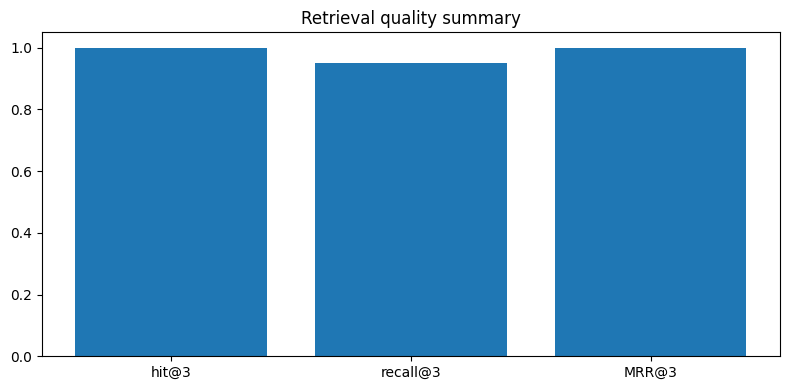

In [14]:
# Сохраняем обязательные и дополнительные артефакты
retrieval_eval.to_csv(ART_DIR / "retrieval_eval.csv", index=False)
rag_examples.to_csv(ART_DIR / "rag_examples.csv", index=False)
retrieval_before_after_update.to_csv(ART_DIR / "retrieval_before_after_update.csv", index=False)

chunks_df[["source_id", "chunk_id", "text"]].head(12).to_csv(ART_DIR / "chunk_examples.csv", index=False)

summary = {
    "seed": SEED,
    "embedding_method": "TF-IDF (word + bigram) + L2 normalization",
    "faiss_index": "IndexFlatIP",
    "similarity": "cosine via normalized inner product",
    "chunk_size": chunk_size_main,
    "overlap": overlap_main,
    "top_k": top_k_main,
    "num_documents_before_update": len(docs),
    "num_documents_after_update": len(docs_updated),
    "num_chunks_before_update": int(len(chunks_df)),
    "hit_at_k": hit_at_k,
    "recall_at_k": recall_at_k,
    "mrr_at_k": mrr_at_k,
    "chunk_size_experiment": experiment_results,
}
with open(ART_DIR / "retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

plt.figure(figsize=(8, 4))
plt.bar(["hit@3", "recall@3", "MRR@3"], [hit_at_k, recall_at_k, mrr_at_k])
plt.ylim(0, 1.05)
plt.title("Retrieval quality summary")
plt.tight_layout()
plt.savefig(ART_DIR / "retrieval_quality_plot.png", dpi=150)
plt.show()
